In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

In [5]:
data=pd.read_csv(r'D:\jupyter\2015.csv')
data

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302


In [33]:
data.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

In [5]:
data.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [85]:
print(data.columns)

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')


In [7]:
data.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [ ]:
#نمره خوشحالی تمام کشور ها به طور میانگین از 1 تا 10 نمره 5 است که با خطای بسیار پایینی محاسبه شده است

In [70]:
mean_happines=data.groupby('Region')['Happiness Score'].mean()
mantaghe=mean_happines.idxmax()
adad=mean_happines.max()
mantaghe0=mean_happines.idxmin()
adad0=mean_happines.min()
print(mantaghe,':',adad)
print(mantaghe0,':',adad0)

Australia and New Zealand : 7.285
Sub-Saharan Africa : 4.2028


In [ ]:
# .منطقه استرالیا و نیوزلند بیشترین امار خوشحالی را در مناطق جهان با میانگین عددی 7.2 دارد 
#جنوب صحرای افریقا غمگین ترین مردم را دارد 

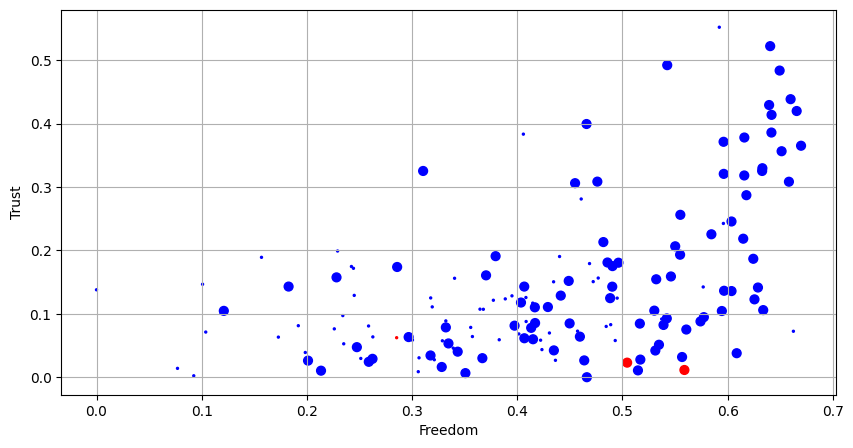

In [19]:
data['color']=data['Standard Error'].apply(lambda x: 'blue' if x<0.1 else 'red')
data['size']=data['Happiness Score'].apply(lambda x:40 if x>5 else 2 )
plt.figure(figsize=(10,5))
plt.scatter(data['Freedom'],data['Trust (Government Corruption)'], s=data['size'], c=data['color'])
plt.xlabel('Freedom')
plt.ylabel('Trust')
plt.grid()
plt.show()

In [ ]:
# خطای این داده ها خیلی ناچیزه چون کلا سه تا داده ای داریم که با خطا محاسبه شدن و نیاز به حذف سدن ان ها نیست
#هر چقدر ازادی بیش تر میشه  اعتماد مردم به دولت افزایش پیدا میکنه
#اگر بخواهیم تاثیر ازادی و اهتماد به دولت رو بر روی میزان خوشحالی باهم مقایسه کنیم  تاثیر اعتماد به دولت مردم بیش تر است

<function matplotlib.pyplot.show(close=None, block=None)>

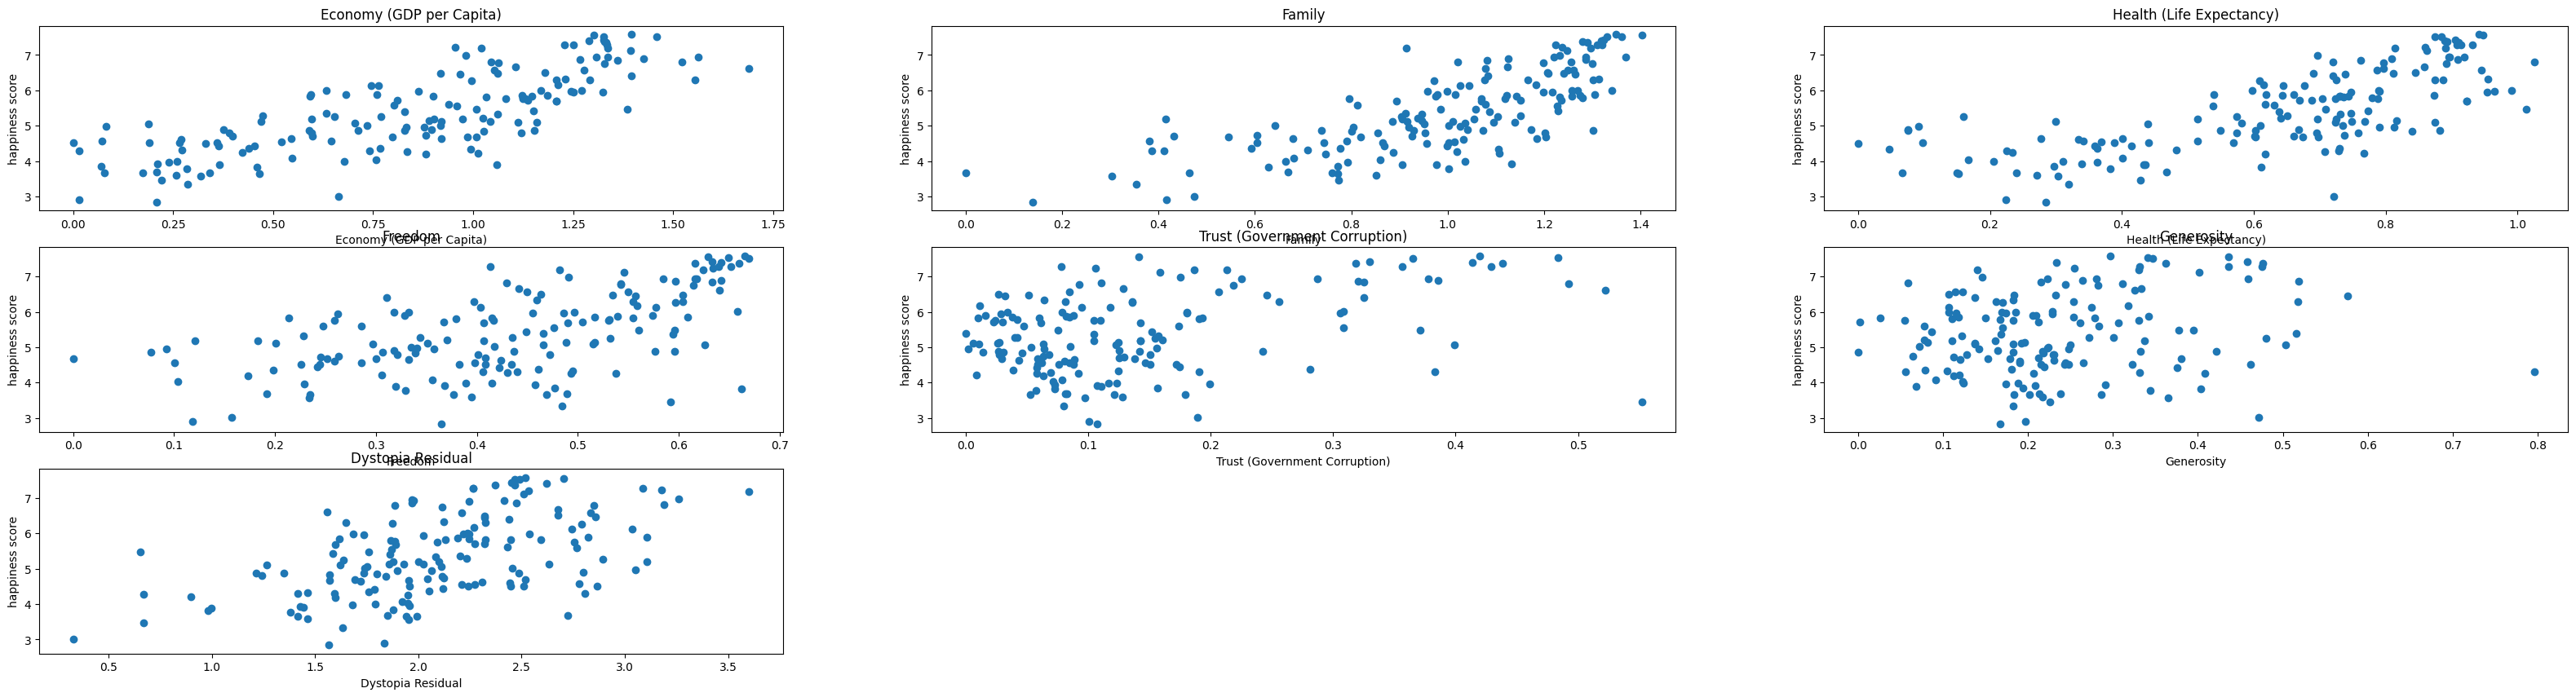

In [69]:
columns=['Economy (GDP per Capita)','Family','Health (Life Expectancy)','Freedom','Trust (Government Corruption)','Generosity',	'Dystopia Residual']
plt.figure(figsize=(40,10))
for i,col in enumerate(columns,1):
    plt.subplot(3,3,i)
    plt.scatter(x=col, y='Happiness Score' , data=data)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('happiness score')
plt.show

In [ ]:
#به طور کلی تاثیر اقتصاد خانواده و سلامتی و ازادی  ارتباط مستقیم با نمره خوشحالی دارد (نمودار درحالت سعودی قرار دارد اما در سه حالت دیگر نمودار متمرکز است و تاثیر کمتری دارد)

Family                           0.999991
Health (Life Expectancy)         0.999899
Freedom                          0.999707
Trust (Government Corruption)    0.999919
Generosity                       1.000086
Dystopia Residual                1.000044
dtype: float64


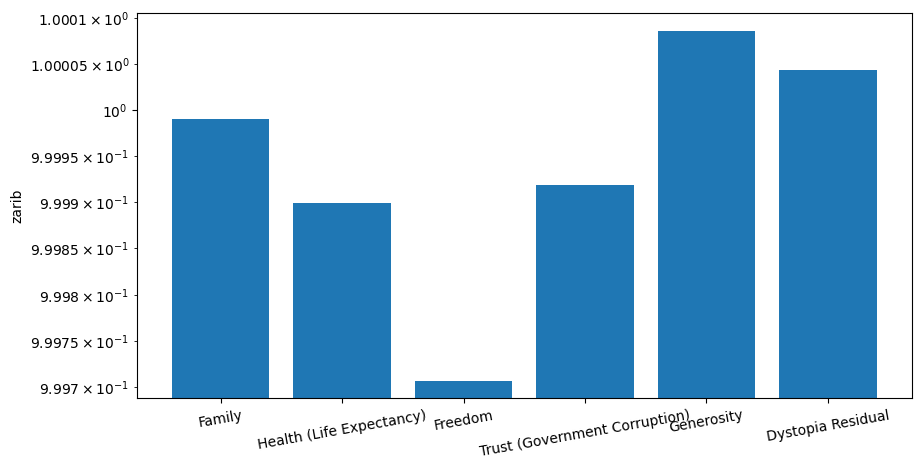

In [61]:
x=data[['Economy (GDP per Capita)','Family','Health (Life Expectancy)','Freedom','Trust (Government Corruption)','Generosity','Dystopia Residual']]
y=data['Happiness Score']
#scale=MinMaxScaler()
model=sm.OLS(y,x).fit()
zarib=model.params[1:]
print(zarib)
plt.figure(figsize=(10,5))
plt.bar(zarib.index,zarib.values)
plt.ylabel('zarib')
plt.yscale('log')
plt.xticks(rotation=10)
plt.show()

In [ ]:
# :این ضرایب به دست امده به این معنا است که مثلا اگر ضریب ستون سخاوت برابر یک است یه این منا است که
# به ازای افزایش هر واحد از ستون سخاوت, یک نمره به نمره خوشحالی اضافه میشود
# :ترتیب تاثیر هر ستون بر نمره خوشحالی به صورت زیر است 
#generosity>distopia>family>trust(goverment corruption)>hehth(life expentancy)>freedom

In [65]:
high=data[data['Happiness Score']>5]['Family']
low=data[data['Happiness Score']<5]['Family']
t,p=stats.ttest_ind(high,low)
x=0.05
if p<x:
    print('family is efective')
else:
    print('family is not efective')

family is efective


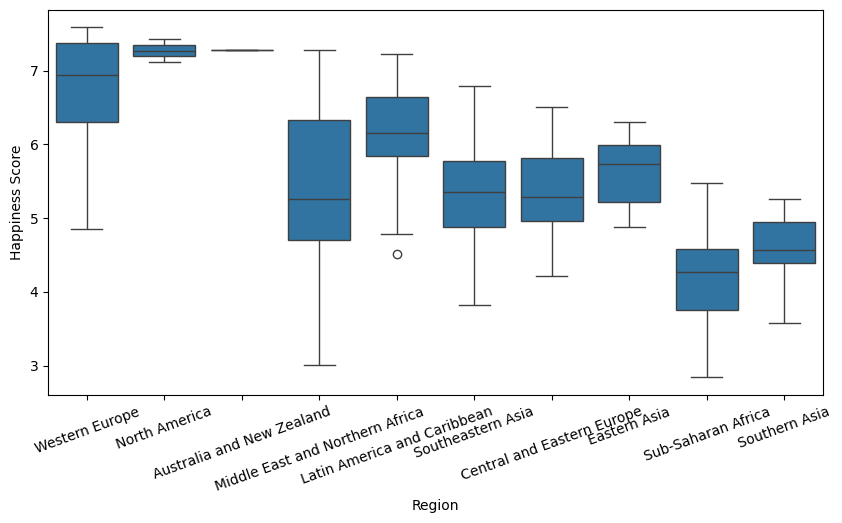

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Region', y='Happiness Score' , data=data)
plt.xlabel('Region')
plt.ylabel('Happiness Score')
plt.xticks(rotation=20)
plt.show()


In [ ]:
# در منطقه استرالیا و نیوزلند کم ترین پراکندگی رو داره و یک جامعه پایدر و همگون است 
# به طور کلی دو تا از دلایل اصلی پراکندگی کم, ازادی و ثبات اقتصادی است که در دو نمودار پایین برسی خواهیم کرد 
#  منطقه خاورمیانه و شمال افریقا بیش ترین پراکندگی را دارد که به معنای تنوع بالای نوسانات احساس خوشجالی است 
# امریکای لاتین یک داده دور افتاده دارد که میتواند نشان دهنده وضعیت خاص یا شرایط غیر معقول باشد
#میانگین خوشحالی امریکای شمالی و استرالیا تقریبا یکسان است

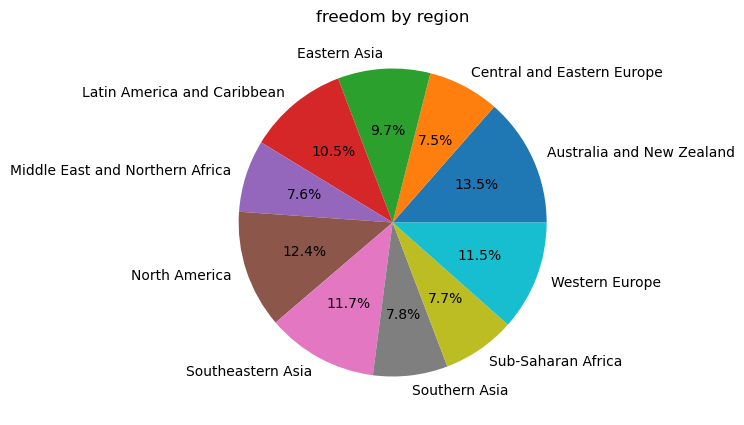

In [92]:
free=data.groupby('Region')['Freedom'].mean()
plt.figure(figsize=(10,5))
plt.pie(free,labels=free.index,autopct='%1.1f%%')
plt.title('freedom by region')
plt.show()

In [ ]:
#همانطور که در اسلاید بالا دیدیم منطقه استرالیا خوشحال تر است و پراکندگی کم تری دارد که یکی از دلایلی که باعث میشود پراکندگی کم تر باشد ازادی فردی یک کشور است

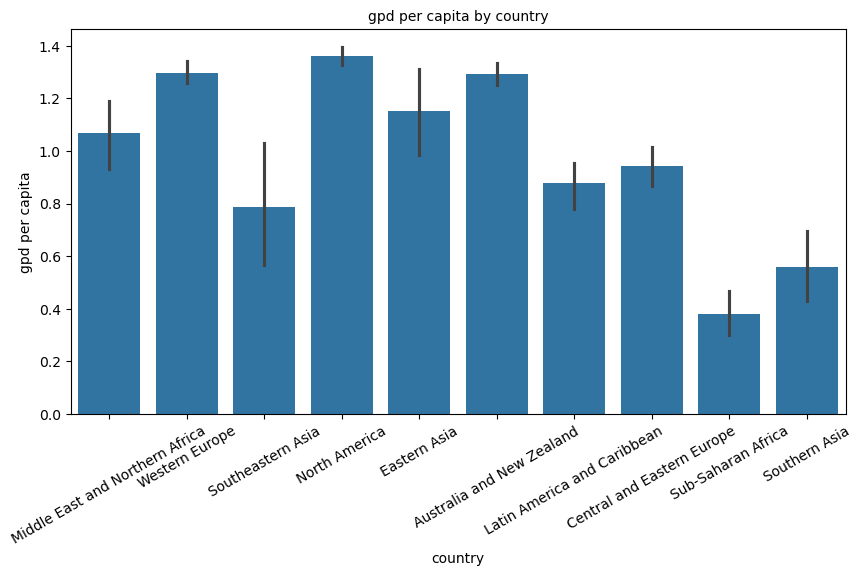

In [88]:
plt.figure(figsize=(10,5))
sns.barplot(x='Region',y='Economy (GDP per Capita)',data= data.sort_values('Economy (GDP per Capita)', ascending=False))
plt.xlabel('country')
plt.ylabel('gpd per capita')
plt.title('gpd per capita by region')
plt.xticks(rotation=30)
plt.show()

In [ ]:
#منطقه صحرای جنوب امریکا بدترین وضعست اقتصادی را در منطقه دارد ولی منطقه امریکای شمالی بهترین  وضعیت اقتصادی را دارد
#با این که امریکا شمالی رتبه اول اقتصاد را دارد اما خوشحال ترین منطقه نیست و استرالیا با رتبه دوم خوشحال ترین است